In [37]:
import os, glob
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve

In [38]:
class UCFFrameDataset(Dataset):
    def __init__(self, root_dir, transform=None, frames_per_clip=16, stride=16, normal_only=False):
        self.samples = []
        self.transform = transform
        self.frames_per_clip = frames_per_clip
        self.stride = stride
        self.normal_only = normal_only

        for cls in os.listdir(root_dir):
            class_dir = os.path.join(root_dir, cls)
            if not os.path.isdir(class_dir):
                continue
            label = 0 if cls == "NormalVideos" else 1
            if self.normal_only and label == 1:
                continue

            frame_paths = sorted(glob.glob(os.path.join(class_dir, "*.png")))
            for start in range(0, len(frame_paths) - frames_per_clip + 1, stride):
                clip_paths = frame_paths[start:start+frames_per_clip]
                self.samples.append((clip_paths, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame_paths, label = self.samples[idx]
        frames = []
        for path in frame_paths:
            img = Image.open(path).convert("RGB")
            if self.transform:
                img = self.transform(img)
            frames.append(img)

        video_tensor = torch.stack(frames)  # (T, C, H, W)
        video_tensor = video_tensor.permute(1, 0, 2, 3)  # (C, T, H, W)
        return video_tensor, label

In [39]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.45,0.45,0.45], std=[0.225,0.225,0.225])
])

train_dataset = UCFFrameDataset(
    r"../Data/UCF-Crime-Dataset/Train",
    transform=transform,
    frames_per_clip=16,
    stride=16,
    normal_only=True
)

test_dataset = UCFFrameDataset(
    r"../Data/UCF-Crime-Dataset/Test",
    transform=transform,
    frames_per_clip=16,
    stride=16
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

Train samples: 59235
Test samples: 6950


In [40]:
i3d = torch.hub.load('facebookresearch/pytorchvideo', 'i3d_r50', pretrained=True)
i3d.blocks[-1].proj = nn.Identity()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
i3d = i3d.to(device)
i3d.eval()

Using cache found in C:\Users\risha/.cache\torch\hub\facebookresearch_pytorchvideo_main


Net(
  (blocks): ModuleList(
    (0): ResNetBasicStem(
      (conv): Conv3d(3, 64, kernel_size=(5, 7, 7), stride=(1, 2, 2), padding=(2, 3, 3), bias=False)
      (norm): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation): ReLU()
      (pool): MaxPool3d(kernel_size=(1, 3, 3), stride=(1, 2, 2), padding=[0, 1, 1], dilation=1, ceil_mode=False)
    )
    (1): ResStage(
      (res_blocks): ModuleList(
        (0): ResBlock(
          (branch1_conv): Conv3d(64, 256, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
          (branch1_norm): BatchNorm3d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (branch2): BottleneckBlock(
            (conv_a): Conv3d(64, 64, kernel_size=(3, 1, 1), stride=(1, 1, 1), padding=(1, 0, 0), bias=False)
            (norm_a): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (act_a): ReLU()
            (conv_b): Conv3d(64, 64, kernel_size=(1,

In [41]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=2048, hidden_dim=512):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim//2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [42]:
autoencoder = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-4)

train_losses = []
epochs = 20

for epoch in range(epochs):
    autoencoder.train()
    total_loss = 0
    for videos, _ in train_loader:
        videos = videos.to(device)
        with torch.no_grad():
            features = i3d(videos)
        features = features.view(features.size(0), -1)

        outputs = autoencoder(features)
        loss = criterion(outputs, features)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/20, Loss: 0.0045
Epoch 2/20, Loss: 0.0024
Epoch 3/20, Loss: 0.0020
Epoch 4/20, Loss: 0.0019
Epoch 5/20, Loss: 0.0018
Epoch 6/20, Loss: 0.0017
Epoch 7/20, Loss: 0.0017
Epoch 8/20, Loss: 0.0017
Epoch 9/20, Loss: 0.0017
Epoch 10/20, Loss: 0.0017


KeyboardInterrupt: 

In [43]:
torch.save(autoencoder.state_dict(), "autoencoder_ucfcrime_epoch10.pth")
print("Model saved to autoencoder_ucfcrime_epoch10.pth")

Model saved to autoencoder_ucfcrime_epoch10.pth


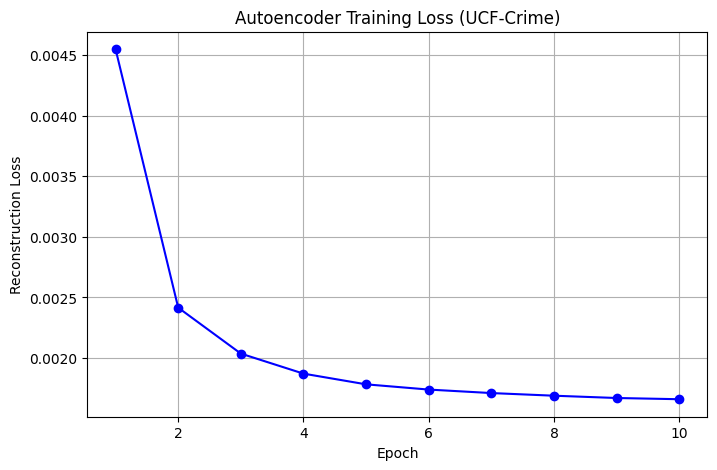

In [45]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', color='blue')
plt.title("Autoencoder Training Loss (UCF-Crime)")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.grid(True)
plt.show()

In [46]:
autoencoder.eval()
errors, labels_list = [], []

with torch.no_grad():
    for videos, labels in test_loader:
        videos = videos.to(device)
        features = i3d(videos)
        features = features.view(features.size(0), -1)

        outputs = autoencoder(features)
        loss = torch.mean((outputs - features)**2, dim=1)

        errors.extend(loss.cpu().numpy())
        labels_list.extend(labels.numpy())

errors = np.array(errors)
labels_list = np.array(labels_list)

# Threshold at 95th percentile of normal errors
threshold = np.percentile(errors[labels_list==0], 95)
y_pred = (errors > threshold).astype(int)
y_true = labels_list

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, errors)

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"AUC: {auc:.3f}")

Precision: 0.644
Recall: 0.127
F1-score: 0.212
AUC: 0.611


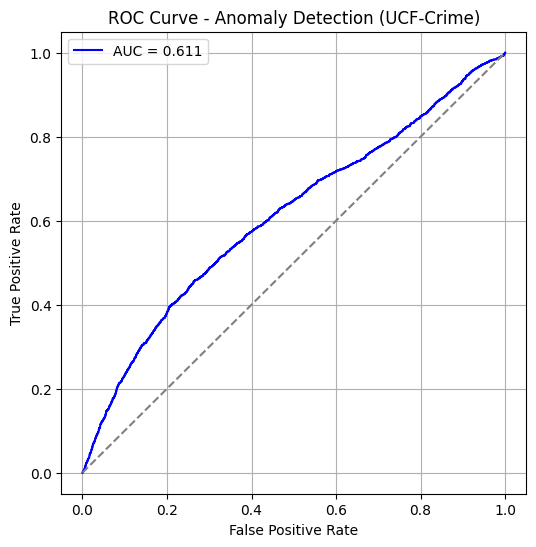

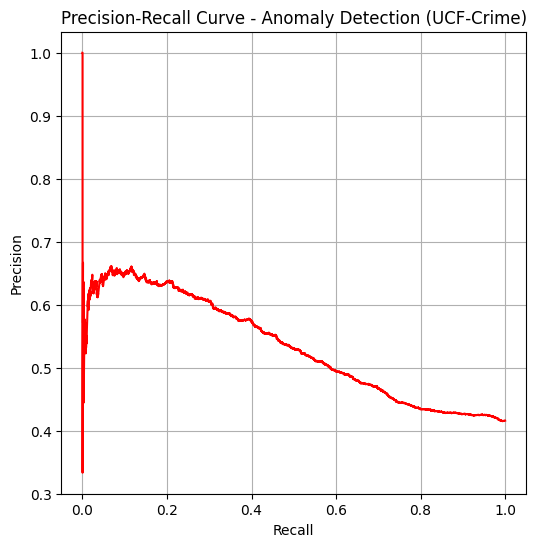

In [47]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_true, errors)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color="blue")
plt.plot([0,1],[0,1],'--',color="gray")
plt.title("ROC Curve - Anomaly Detection (UCF-Crime)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_true, errors)
plt.figure(figsize=(6,6))
plt.plot(rec, prec, color="red")
plt.title("Precision-Recall Curve - Anomaly Detection (UCF-Crime)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

In [ ]:
# Reload later
#autoencoder = Autoencoder().to(device)
#autoencoder.load_state_dict(torch.load("autoencoder_ucfcrime.pth"))
#autoencoder.eval()
#print("Model loaded and ready for inference.")